Processed data file not found. Processing gradients...


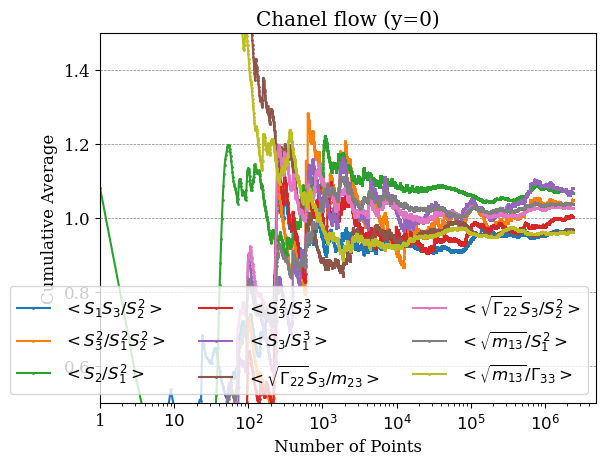

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-inv-ch00-fromfile.npy')
        print("Loaded existing processed data from 'AtA-inv-ch00-fromfile.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-inv-ch00-fromfile.npy', inv)

process_from_file()

InvLoad=np.load('AtA-inv-ch00-fromfile.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000, 1000000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$', '$10^6$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [5]:
len(InvLoad[0])

2370288

Loaded existing processed data from 'AtA-channel-0999-from-file.npy'


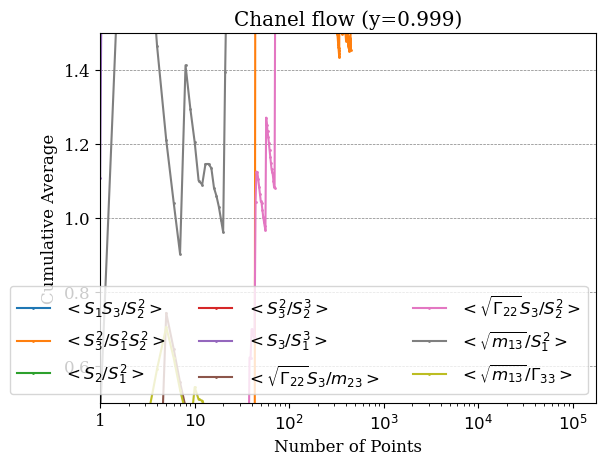

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0999-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0999-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0999.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0999-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0999-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.999)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0999.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [13]:
len(InvLoad[0])

99120

Processed data file not found. Processing gradients...


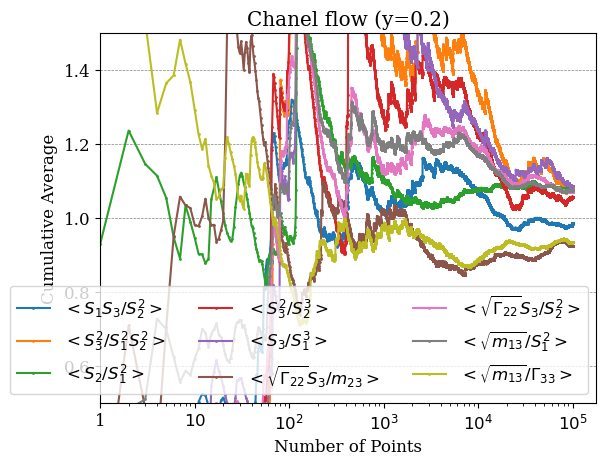

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-02-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-02-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-02.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-02-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-02-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.2)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-02.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


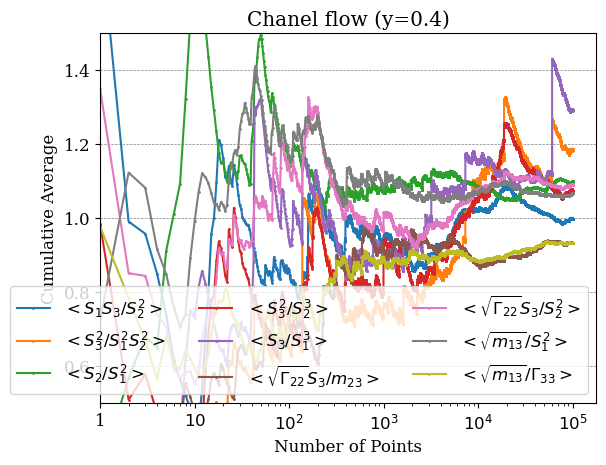

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-04-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-04-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-04.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-04-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-04-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.4)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-04.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


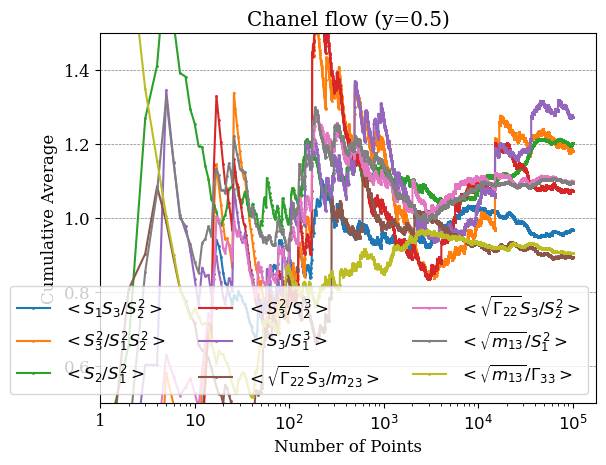

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-05-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-05-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-05.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-05-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-05-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.5)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-05.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


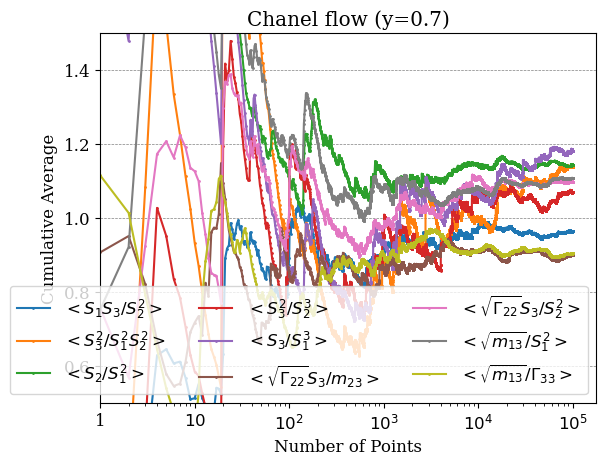

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-07-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-07-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-07.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-07-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-07-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.7)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-07.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


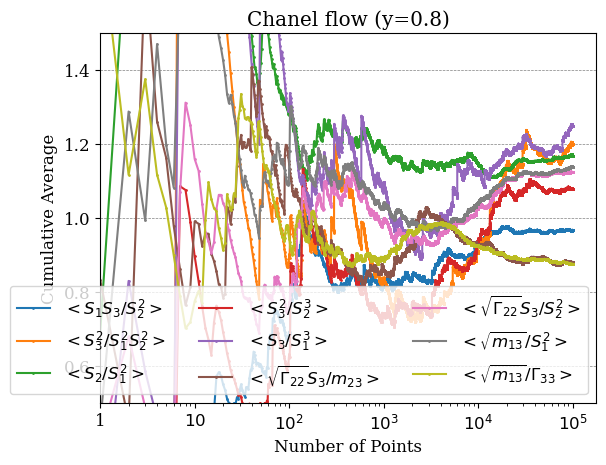

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-08-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-08-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-08.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-08-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-08-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.8)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-08.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


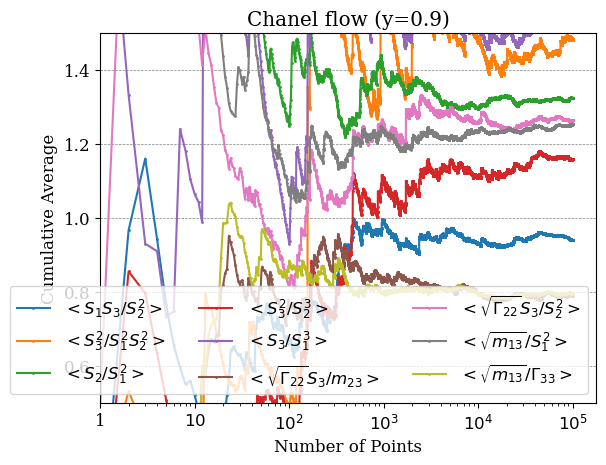

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-09-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-09-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-09.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-09-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-09-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.9)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-09.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


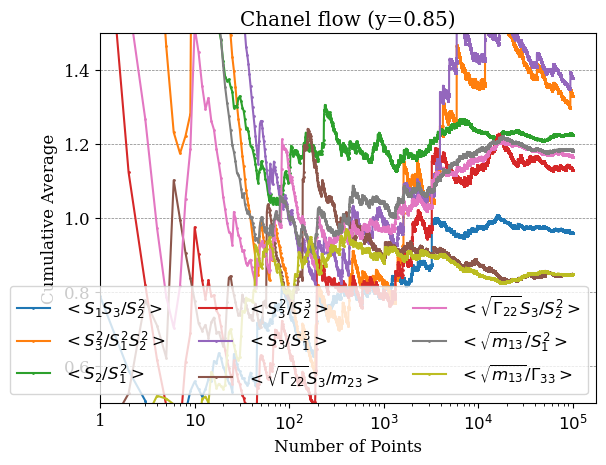

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-085-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-085-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-085.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-085-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-085-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.85)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-085.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


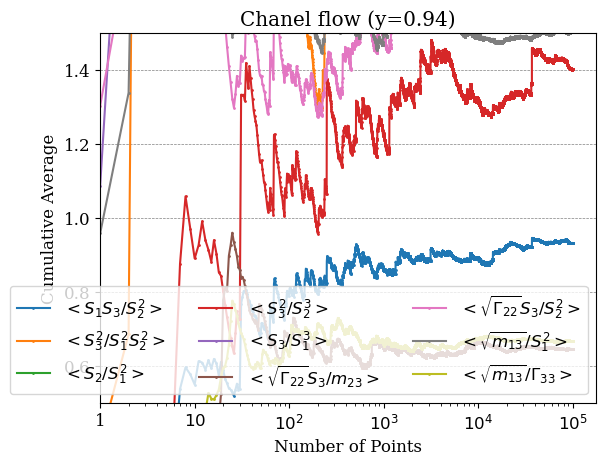

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-094-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-094-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-094.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-094-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-094-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.94)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-094.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


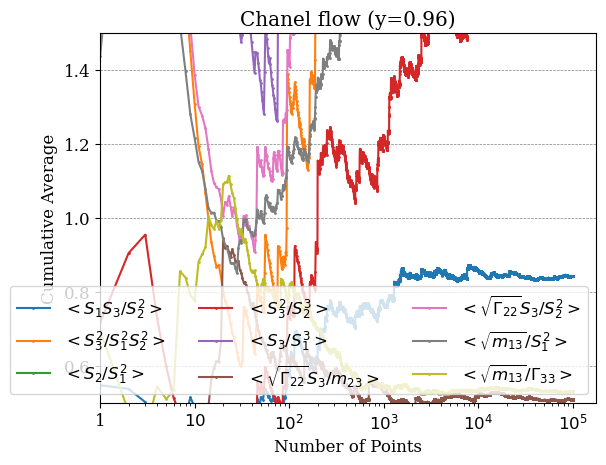

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-096-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-096-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-096.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-096-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-096-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.96)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-096.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


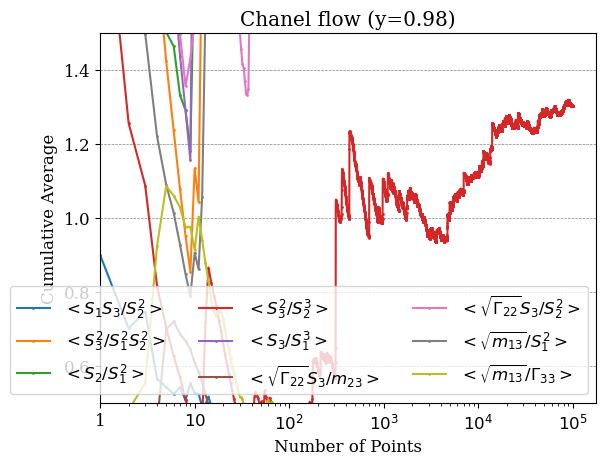

In [23]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-098-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-098-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-098.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-098-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-098-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.98)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-098.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


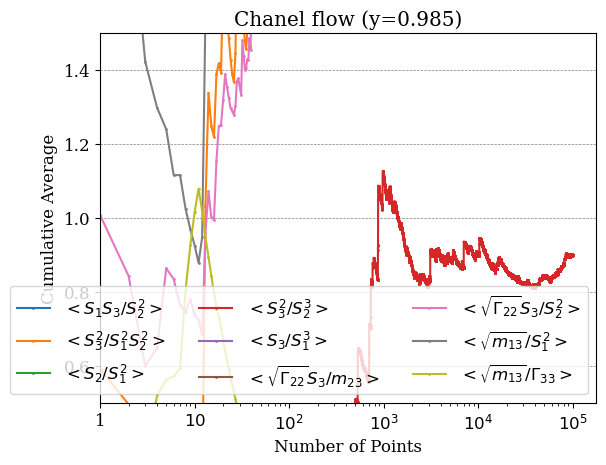

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0985-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0985-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0985.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0985-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0985-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.985)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0985.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


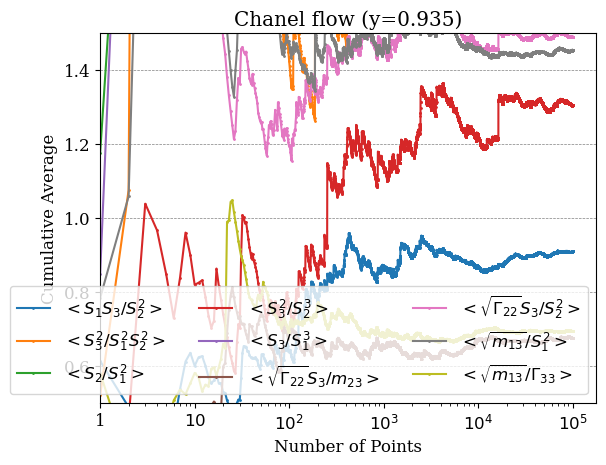

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0935-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0935-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0935.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0935-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0935-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.935)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0935.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


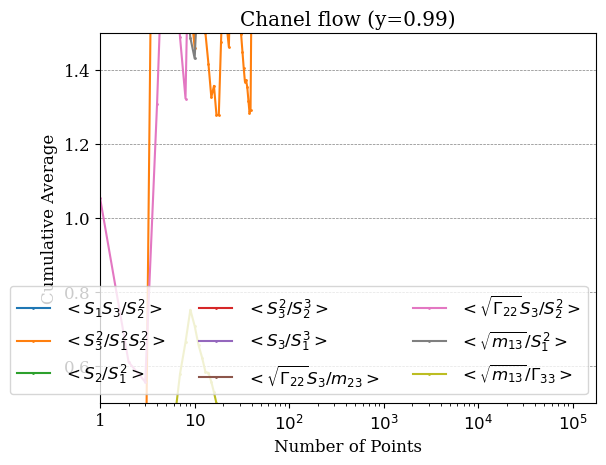

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-099-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-099-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-099.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-099-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-099-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.99)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-099.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


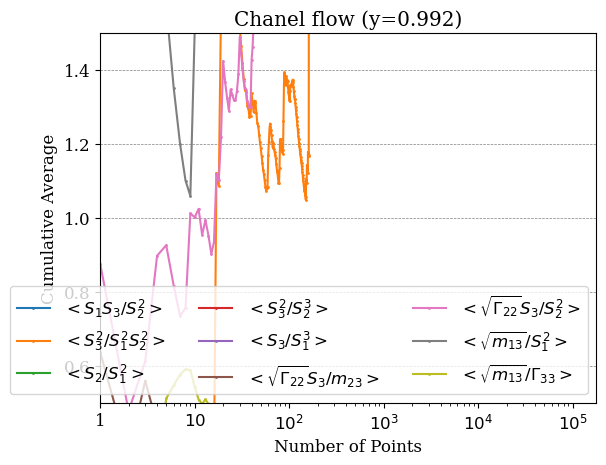

In [27]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0992-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0992-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0992.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0992-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0992-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.992)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0992.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


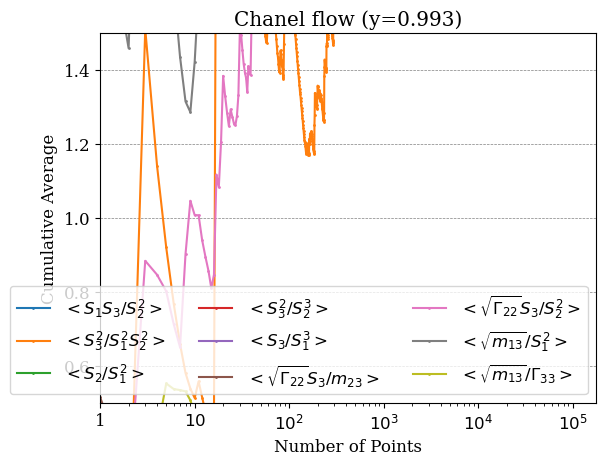

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0993-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0993-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0993.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0993-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0993-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.993)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0993.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


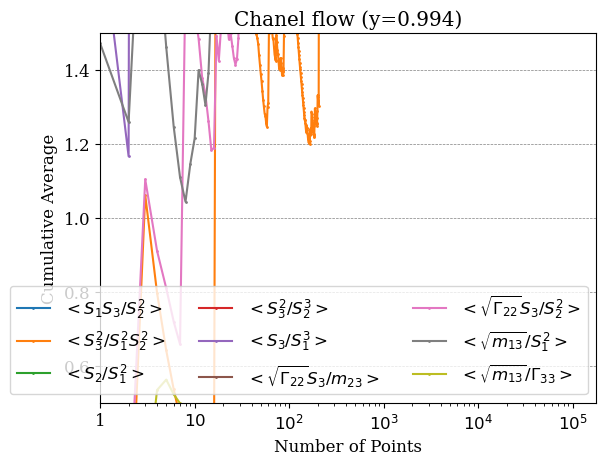

In [29]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0994-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0994-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0994.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0994-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0994-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.994)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0994.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


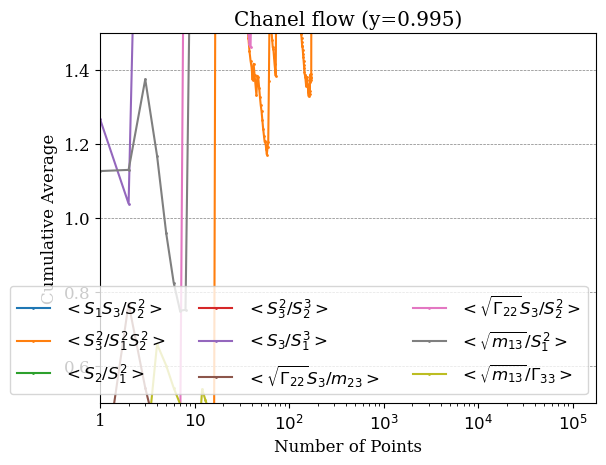

In [30]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0995-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0995-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0995.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0995-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0995-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.995)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0995.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


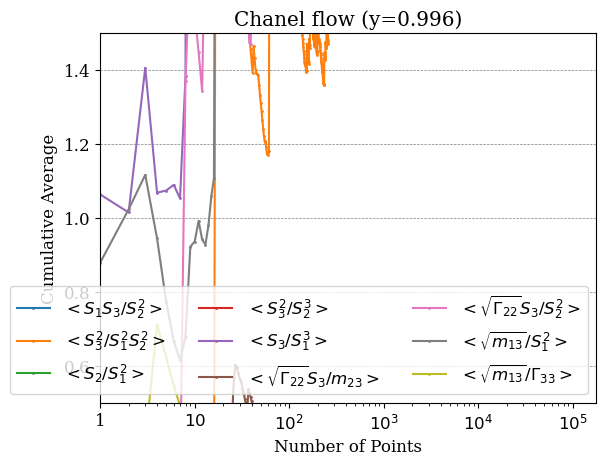

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0996-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0996-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0996.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0996-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0996-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.996)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0996.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


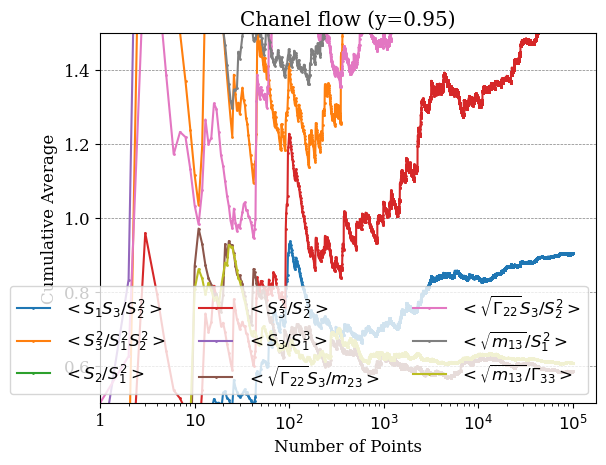

In [32]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-095-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-095-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-095.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-095-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-095-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.95)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-095.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


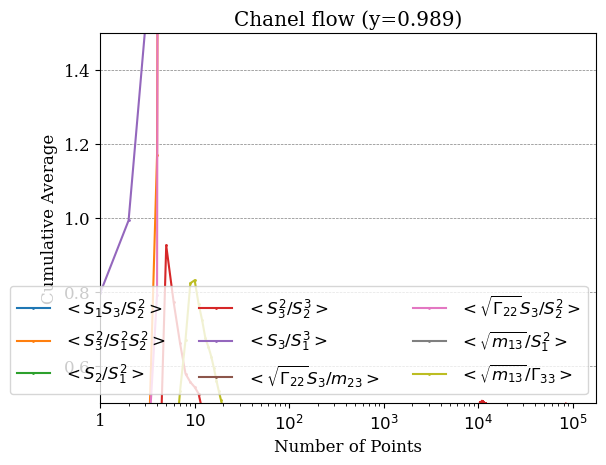

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0989-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0989-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0989.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0989-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0989-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.989)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0989.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


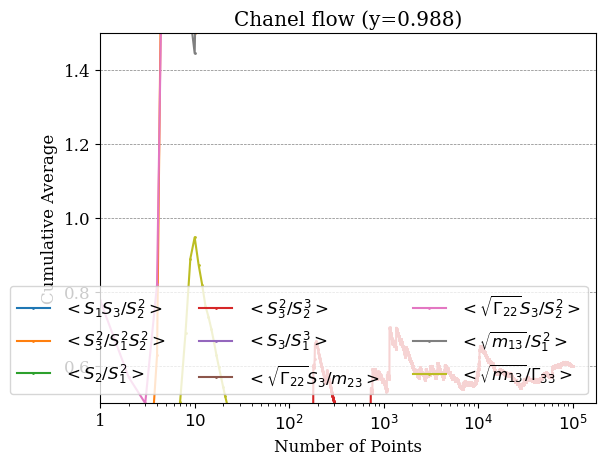

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0988-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0988-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0988.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0988-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0988-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.988)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0988.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


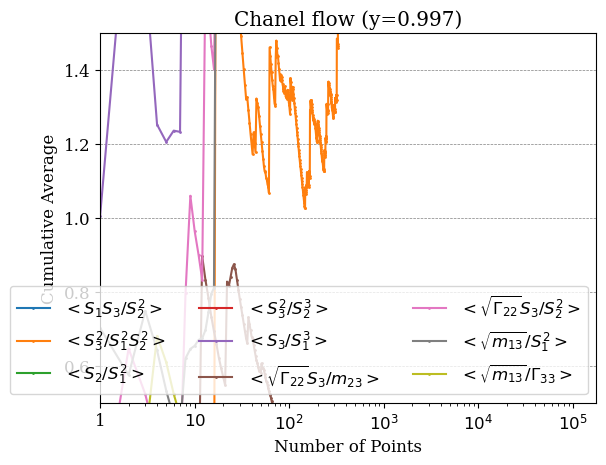

In [37]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0997-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0997-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0997.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0997-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0997-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.997)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0997.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


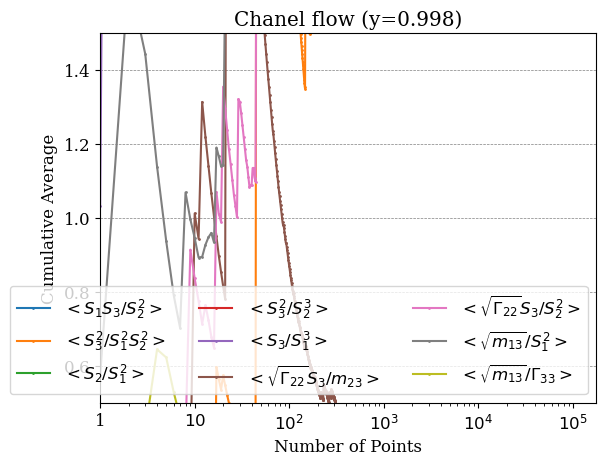

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0998-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0998-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0998.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0998-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0998-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.998)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0998.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


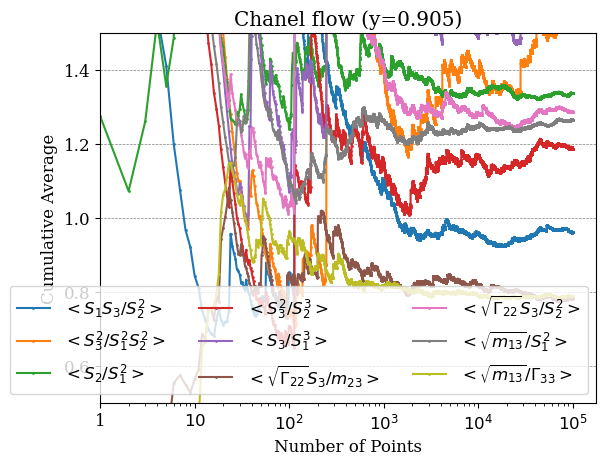

In [46]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0905-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0905-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0905.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0905-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0905-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.905)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0905.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


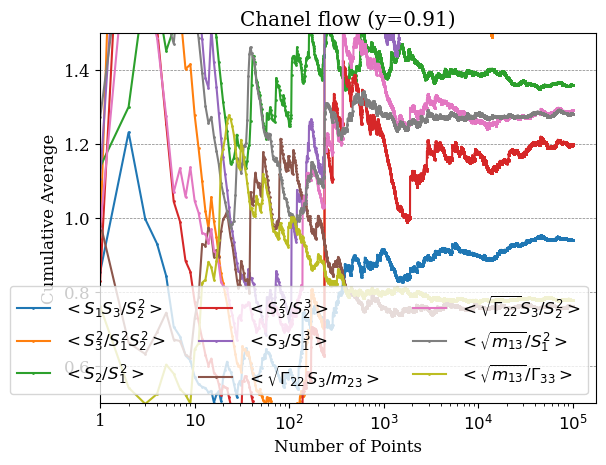

In [48]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-091-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-091-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-091.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-091-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-091-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.91)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-091.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


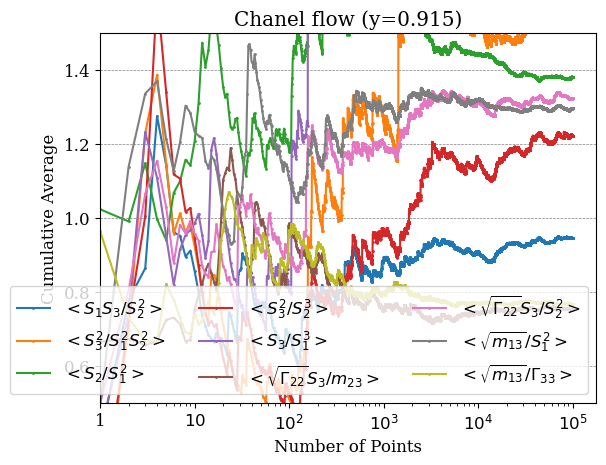

In [50]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0915-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0915-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0915.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0915-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0915-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.915)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0915.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


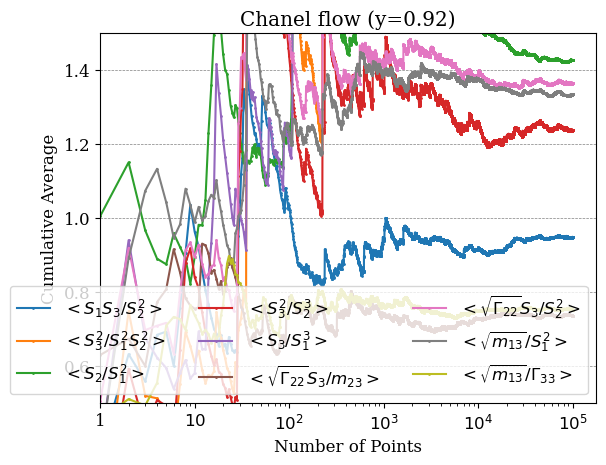

In [52]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-092-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-092-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-092.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-092-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-092-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.92)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-092.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


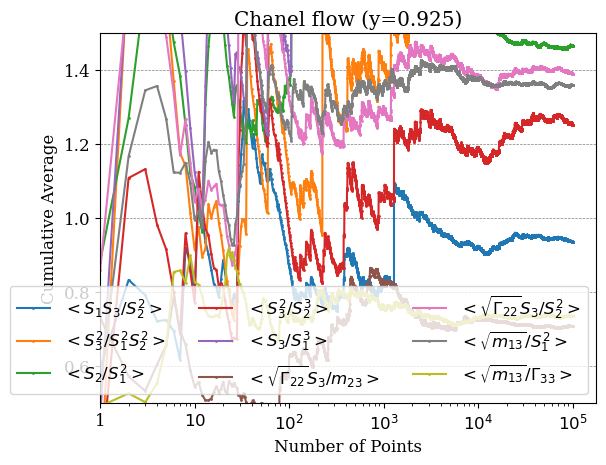

In [54]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-099-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0925-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0925.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0925-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0925-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.925)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0925.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Loaded existing processed data from 'AtA-channel-093-from-file.npy'


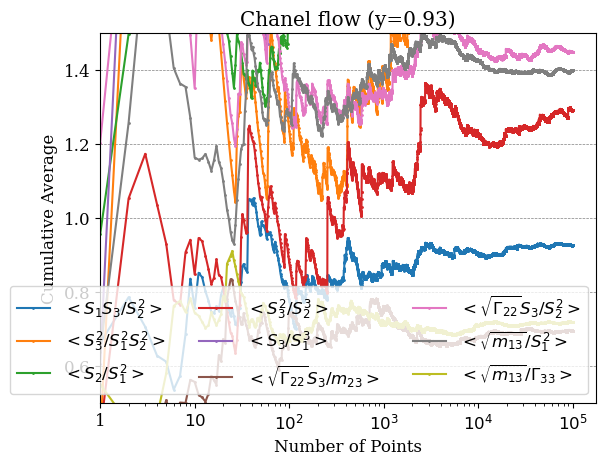

In [57]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-093-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-093-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-093.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-093-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-093-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.93)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-093.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


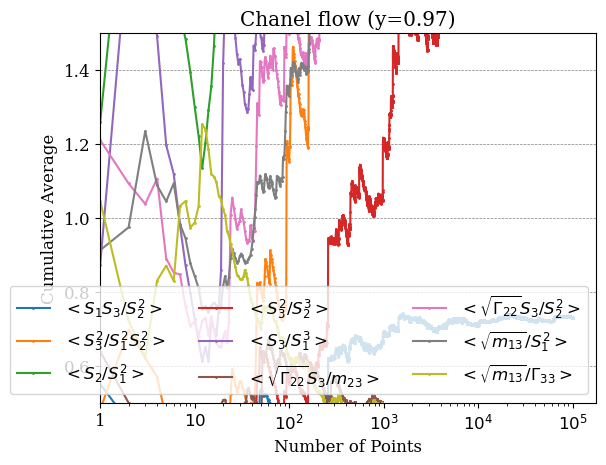

In [60]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-097-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-097-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-097.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-097-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-097-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.97)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-097.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


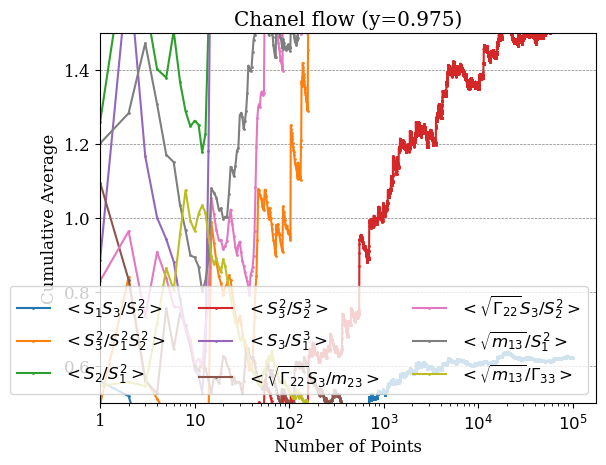

In [62]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0975-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0975-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0975.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0975-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0975-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.975)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0975.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


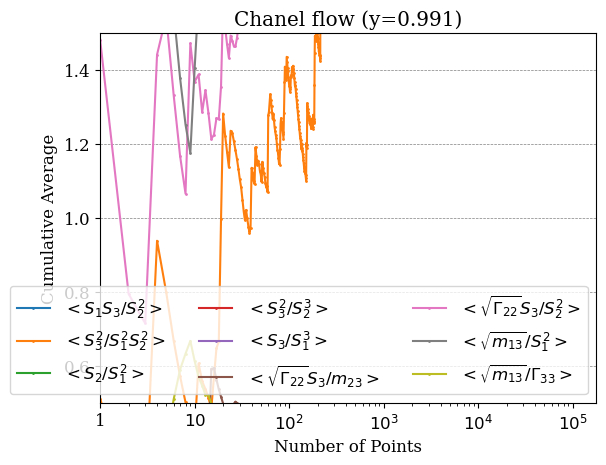

In [65]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0991-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0991-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0991.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((9, len(S1)), dtype=np.float32)
    inv[0, :] = S3 / (S1**3)
    inv[1, :] = S2 / (S1**2)
    inv[2, :] = (S3**2) / (S2**3)
    inv[3, :] = (S3**2) / (S1**2 * S2**2)
    inv[4, :] = (S1 * S3) / (S2**2)
    inv[5, :] = np.sqrt(g22) * S3/ m23
    inv[6, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[7, :] = np.sqrt(m13) / (S1**2)
    inv[8, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0991-from-file.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0991-from-file.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<S_2/S_1^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$')
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<S_3/S_1^3>$')
plt.plot(indices, AverChan[5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[6], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[8], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Chanel flow (y=0.991)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=3)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', axis='y')

# Setting logarithmic scale for x-axis
plt.xscale('log')

# Setting the x-axis limits to start from 1
plt.xlim(left=1)

# Customizing the x-axis ticks
custom_xticks = [1, 10, 100, 1000, 10000, 100000]  # Custom tick positions
custom_xticklabels = ['1','$10$','$10^2$','$10^3$', '$10^4$','$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0991.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

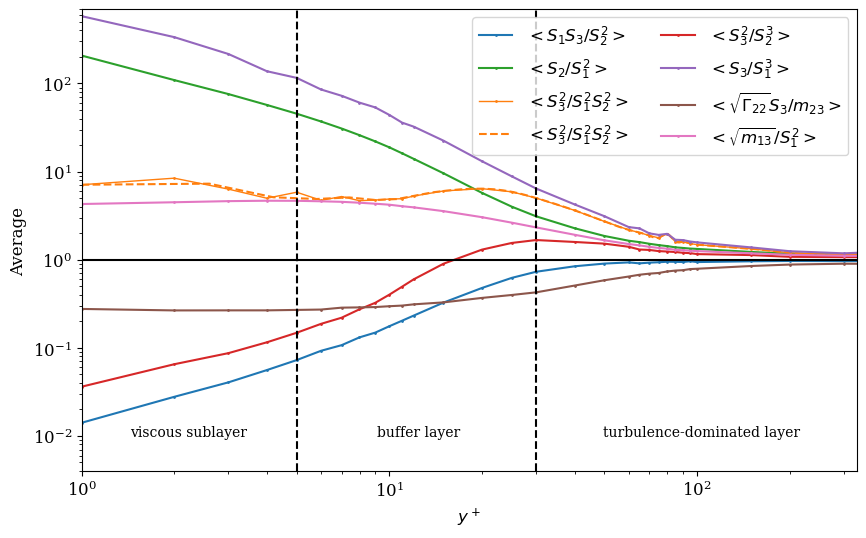

In [88]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

# Distances from the wall
DstncFromWall = [0.2, 0.4, 0.5, 0.7, 0.8, 0.85, 0.9, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.95, 0.96, 0.97, 0.975, 0.98, 0.985, 0.988, 0.989, 0.99, 0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999]

# Load all the arrays
arrays = [
    np.load(f'AtA-channel-{d}-from-file.npy') for d in DstncFromWall
]

# Calculate y^+ values
y_plus = 1000 * (1 - np.array(DstncFromWall)) / 1.0006

# Define the new order of colors manually
colors = ['C0', 'C2', 'C1', 'C3', 'C4', 'C5', 'C6']

# Calculate the average of each array
averages = np.array([np.mean(arr, axis=1) for arr in arrays])

# Plotting
plt.figure(figsize=(10, 6))

# Plot the average of each index against y^+ with log-log scale
plt.loglog(y_plus, averages[:, 4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$', color=colors[0])
plt.loglog(y_plus, averages[:, 1], marker='o', markersize=1, label='$<S_2/S_1^2>$', color=colors[1])
plt.loglog(y_plus, averages[:, 3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$', color=colors[2], linewidth=1)
# Smooth the plot for averages[:, 3]
smooth_y_plus = np.linspace(y_plus.min(), y_plus.max(), 500)
smooth_averages_3 = interp1d(y_plus, averages[:, 3], kind='cubic')(smooth_y_plus)

# Apply moving average to the noisy part
window_size = 15  # Adjust the window size as needed
smoothed_averages_3 = np.convolve(averages[:, 3], np.ones(window_size)/window_size, mode='same')

plt.loglog(smooth_y_plus, smooth_averages_3, label='$<S_3^2/S_1^2 S_2^2>$', color=colors[2], linestyle='--')
plt.loglog(y_plus, averages[:, 2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$', color=colors[3])
plt.loglog(y_plus, averages[:, 0], marker='o', markersize=1, label='$<S_3/S_1^3>$', color=colors[4])
plt.loglog(y_plus, averages[:, 5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$', color=colors[5])
plt.loglog(y_plus, averages[:, 7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$', color=colors[6])

for i in range(averages.shape[1]):
    plt.loglog(label=f'Average(InvLoad[{i}])')

y_plus_min=1
y_plus_visc=5
y_plus_turb=30
y_plus_max=330
pos_1=np.sqrt(y_plus_min * y_plus_visc)-.8
pos_2=np.sqrt(y_plus_visc * y_plus_turb)-3.1
pos_3=np.sqrt(y_plus_turb * y_plus_max)-50

# Add vertical lines for y^+ = 5 and y^+ = 30
plt.axvline(x=y_plus_visc, color='black', linestyle='--')
plt.axvline(x=y_plus_turb, color='black', linestyle='--')

# Add horizontal line for Average = 1
plt.axhline(y=1, color='black', linestyle='-'#, label='Average = 1'
            )

# Add annotations for intervals
plt.annotate('viscous sublayer', xy=(pos_1, 0.01), xytext=(pos_1, 0.01), fontsize=10, color='black')
plt.annotate('buffer layer', xy=(pos_2, 0.01), xytext=(pos_2, 0.01), fontsize=10, color='black')
plt.annotate('turbulence-dominated layer', xy=(pos_3, 0.01), xytext=(pos_3, 0.01), fontsize=10, color='black')

# Setting the y-axis limits
plt.ylim(bottom=0.004, top=700)  # Adjust 'top' to your desired maximum value
plt.xlim(left=y_plus_min, right=y_plus_max)  # Adjust 'top' to your desired maximum value

#plt.title('Dependence of Average on $y^+$')
plt.xlabel('$y^+$')
plt.ylabel('Average')
plt.legend(loc='upper right', ncol=2)


# Save the plot as a JPEG file
plt.savefig('chan-dpnd.jpg', format='jpeg', dpi=300, bbox_inches='tight')

#plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

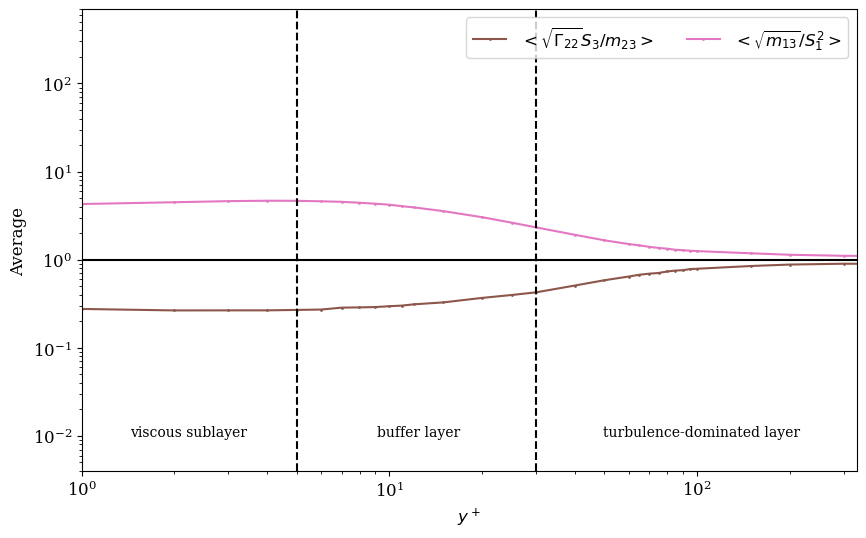

In [77]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

# Distances from the wall
DstncFromWall = [0.2, 0.4, 0.5, 0.7, 0.8, 0.85, 0.9, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.95, 0.96, 0.97, 0.975, 0.98, 0.985, 0.988, 0.989, 0.99, 0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999]

# Load all the arrays
arrays = [
    np.load(f'AtA-channel-{d}-from-file.npy') for d in DstncFromWall
]

# Calculate y^+ values
y_plus = 1000 * (1 - np.array(DstncFromWall)) / 1.0006

# Define the new order of colors manually
colors = ['C0', 'C2', 'C1', 'C3', 'C4', 'C5', 'C6']

# Calculate the average of each array
averages = np.array([np.mean(arr, axis=1) for arr in arrays])

# Plotting
plt.figure(figsize=(10, 6))

# Plot the average of each index against y^+ with log-log scale
#plt.loglog(y_plus, averages[:, 4], marker='o', markersize=1, label='$<S_1 S_3/S_2^2>$', color=colors[0])
#plt.loglog(y_plus, averages[:, 1], marker='o', markersize=1, label='$<S_2/S_1^2>$', color=colors[1])
#plt.loglog(y_plus, averages[:, 3], marker='o', markersize=1, label='$<S_3^2/S_1^2 S_2^2>$', color=colors[2])
#plt.loglog(y_plus, averages[:, 2], marker='o', markersize=1, label='$<S_3^2/S_2^3>$', color=colors[3])
#plt.loglog(y_plus, averages[:, 0], marker='o', markersize=1, label='$<S_3/S_1^3>$', color=colors[4])
plt.loglog(y_plus, averages[:, 5], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$', color=colors[5])
plt.loglog(y_plus, averages[:, 7], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$', color=colors[6])

for i in range(averages.shape[1]):
    plt.loglog(label=f'Average(InvLoad[{i}])')

y_plus_min=1
y_plus_visc=5
y_plus_turb=30
y_plus_max=330
pos_1=np.sqrt(y_plus_min * y_plus_visc)-.8
pos_2=np.sqrt(y_plus_visc * y_plus_turb)-3.1
pos_3=np.sqrt(y_plus_turb * y_plus_max)-50

# Add vertical lines for y^+ = 5 and y^+ = 30
plt.axvline(x=y_plus_visc, color='black', linestyle='--')
plt.axvline(x=y_plus_turb, color='black', linestyle='--')

# Add horizontal line for Average = 1
plt.axhline(y=1, color='black', linestyle='-'#, label='Average = 1'
            )

# Add annotations for intervals
plt.annotate('viscous sublayer', xy=(pos_1, 0.01), xytext=(pos_1, 0.01), fontsize=10, color='black')
plt.annotate('buffer layer', xy=(pos_2, 0.01), xytext=(pos_2, 0.01), fontsize=10, color='black')
plt.annotate('turbulence-dominated layer', xy=(pos_3, 0.01), xytext=(pos_3, 0.01), fontsize=10, color='black')

# Setting the y-axis limits
plt.ylim(bottom=0.004, top=700)  # Adjust 'top' to your desired maximum value
plt.xlim(left=y_plus_min, right=y_plus_max)  # Adjust 'top' to your desired maximum value

#plt.title('Dependence of Average on $y^+$')
plt.xlabel('$y^+$')
plt.ylabel('Average')
plt.legend(loc='upper right', ncol=2)


# Save the plot as a JPEG file
plt.savefig('chan-dpnd.jpg', format='jpeg', dpi=300, bbox_inches='tight')

#plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

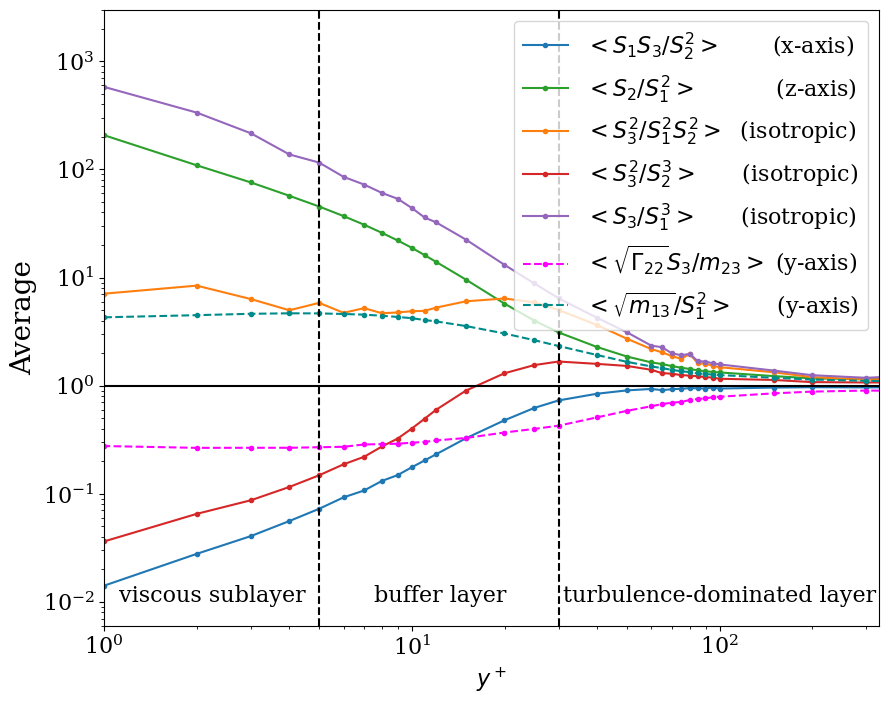

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = "serif"

# Distances from the wall
DstncFromWall = [0.2, 0.4, 0.5, 0.7, 0.8, 0.85, 0.9, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.95, 0.96, 0.97, 0.975, 0.98, 0.985, 0.988, 0.989, 0.99, 0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999]

# Load all the arrays
arrays = [
    np.load(f'AtA-channel-{d}-from-file.npy') for d in DstncFromWall
]

# Calculate y^+ values
y_plus = 1000 * (1 - np.array(DstncFromWall)) / 1.0006

# Define the new order of colors manually
colors = ['C0', 'C2', 'C1', 'C3', 'C4', 'magenta', 'darkcyan']

# Calculate the average of each array
averages = np.array([np.mean(arr, axis=1) for arr in arrays])

# Plotting
plt.figure(figsize=(10, 8))

# Plot the average of each index against y^+ with log-log scale
plt.loglog(y_plus, averages[:, 4], marker='o', markersize=3, label='$<S_1 S_3/S_2^2>$       (x-axis)', color=colors[0])
plt.loglog(y_plus, averages[:, 1], marker='o', markersize=3, label='$<S_2/S_1^2>$           (z-axis)', color=colors[1])
# Smooth the plot for averages[:, 3]
#smooth_y_plus = np.linspace(y_plus.min(), y_plus.max(), 500)
#smooth_averages_3 = interp1d(y_plus, averages[:, 3], kind='cubic')(smooth_y_plus)

# Calculate the mean for the last few points
#window_size = 12  # Adjust the window size as needed
#mean_value = np.mean(averages[-window_size:, 3])

# Create a new array with the mean value for the last points
#smoothed_averages_3 = np.copy(averages[:, 3])
#smoothed_averages_3[-window_size:] = mean_value

# Interpolate the smoothed data
#interp_func = interp1d(y_plus, smoothed_averages_3, kind='cubic')
#smoothed_averages_3_interp = interp_func(smooth_y_plus)

# Plot the smoothed data
#plt.loglog(smooth_y_plus, smoothed_averages_3_interp, label='$<S_3^2/S_1^2 S_2^2>$  (isotropic)', color=colors[2])
plt.loglog(y_plus, averages[:, 3], marker='o', markersize=3, color=colors[2], label='$<S_3^2/S_1^2 S_2^2>$  (isotropic)')#, linestyle='--')

plt.loglog(y_plus, averages[:, 2], marker='o', markersize=3, label='$<S_3^2/S_2^3>$      (isotropic)', color=colors[3])
plt.loglog(y_plus, averages[:, 0], marker='o', markersize=3, label='$<S_3/S_1^3>$      (isotropic)', color=colors[4])
plt.loglog(y_plus, averages[:, 5], marker='o', markersize=3, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$ (y-axis)', color=colors[5], linestyle='--')
plt.loglog(y_plus, averages[:, 7], marker='o', markersize=3, label='$<\sqrt{m_{13}}/S_1^2>$      (y-axis)', color=colors[6], linestyle='--')

y_plus_min=1
y_plus_visc=5
y_plus_turb=30
y_plus_max=330
pos_1=np.sqrt(y_plus_min * y_plus_visc)-1.12
pos_2=np.sqrt(y_plus_visc * y_plus_turb)-4.7
pos_3=np.sqrt(y_plus_turb * y_plus_max)-68.5

# Add vertical lines for y^+ = 5 and y^+ = 30
plt.axvline(x=y_plus_visc, color='black', linestyle='--')
plt.axvline(x=y_plus_turb, color='black', linestyle='--')

# Add horizontal line for Average = 1
plt.axhline(y=1, color='black', linestyle='-'#, label='Average = 1'
            )

# Add annotations for intervals
plt.annotate('viscous sublayer', xy=(pos_1, 0.01), xytext=(pos_1, 0.01), fontsize=16, color='black')
plt.annotate('buffer layer', xy=(pos_2, 0.01), xytext=(pos_2, 0.01), fontsize=16, color='black')
plt.annotate('turbulence-dominated layer', xy=(pos_3, 0.01), xytext=(pos_3, 0.01), fontsize=16, color='black')

# Setting the y-axis limits
plt.ylim(bottom=0.006, top=3000)  # Adjust 'top' to your desired maximum value
plt.xlim(left=y_plus_min, right=y_plus_max)  # Adjust 'top' to your desired maximum value

#plt.title('Dependence of Average on $y^+$')
plt.xlabel('$y^+$')
plt.ylabel('Average', fontsize=20)
plt.legend(loc='upper right', ncol=1)

# Save the plot as a JPEG file
plt.savefig('chan-dpnd.jpg', format='jpeg', dpi=300, bbox_inches='tight')

plt.savefig('chan-dpnd.png', format='png', dpi=300, bbox_inches='tight')

#plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()